In [ ]:
import sys, os
sys.path.append("../bess-optimizer")

from optimizer import optimizer
from matplotlib import pyplot as plt
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

from scipy.stats import mannwhitneyu

In [ ]:
df = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'id3_prices.csv'), index_col=0, parse_dates=True)
index = df.index
df = df.values.repeat(4, axis=1)
df = pd.DataFrame(df).iloc[1:]

df_results = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'predictions.csv'), index_col=0, parse_dates=True)
df_results = df_results.values.repeat(4, axis=1)
df_results = pd.DataFrame(df_results).iloc[1:]

df_pca_results = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'pca_predictions.csv'), index_col=0, parse_dates=True)
df_pca_results = df_pca_results.values.repeat(4, axis=1)
df_pca_results = pd.DataFrame(df_pca_results).iloc[1:]

df_naive = df.shift(1).dropna()

intersect_index = df.index.intersection(df_results.index).intersection(df_pca_results.index).intersection(df_naive.index)
df = df.loc[intersect_index].set_index(index[intersect_index])
df_results = df_results.loc[intersect_index].set_index(index[intersect_index])
df_pca_results = df_pca_results.loc[intersect_index].set_index(index[intersect_index])
df_naive = df_naive.loc[intersect_index].set_index(index[intersect_index])

In [ ]:
# optimize battery on day-ahead predictions
# see: 
energy_cap = 2
power_cap = 1
n_cycles = 1.5

solverpath_exe = '/usr/bin/glpsol'

In [ ]:
# github repo: https://github.com/FlexPwr/bess-optimizer/tree/main
optimizer_flex = optimizer(solverpath_exe=solverpath_exe)

In [ ]:
# code example: https://github.com/FlexPwr/bess-optimizer/blob/main/example.ipynb
def optimize_one_day(pred_vector, actual_vector, energy_cap=2, power_cap=1, n_cycles=1.5):
    step1_soc_daa,step1_cha_daa,step1_dis_daa, step1_profit_daa = optimizer_flex.step1_optimize_daa(n_cycles=n_cycles, energy_cap=energy_cap, power_cap=power_cap, daa_price_vector=pred_vector)
    revenue_daa = np.sum(np.asarray(actual_vector) * (np.asarray(step1_dis_daa) - step1_cha_daa)) * power_cap/4
    return revenue_daa

In [ ]:
df_revenues = pd.DataFrame(index=df.index, columns=['ica', 'pca', 'naive', 'benchmark'])
ica_revenues = Parallel(n_jobs=-1)(delayed(optimize_one_day)(df_results.iloc[i].values, df.iloc[i].values) for i in tqdm(range(len(df_results))))
df_revenues['ica'] = ica_revenues

100%|██████████| 2818/2818 [00:03<00:00, 861.52it/s]


In [ ]:
pca_revenues = Parallel(n_jobs=-1)(delayed(optimize_one_day)(df_pca_results.iloc[i].values, df.iloc[i].values) for i in tqdm(range(len(df_pca_results))))
df_revenues['pca'] = pca_revenues

100%|██████████| 2818/2818 [00:02<00:00, 1059.66it/s]


In [ ]:
naive_revenues = Parallel(n_jobs=-1)(delayed(optimize_one_day)(df_naive.iloc[i].values, df.iloc[i].values) for i in tqdm(range(len(df_naive))))
df_revenues['naive'] = naive_revenues

100%|██████████| 2818/2818 [00:02<00:00, 1160.69it/s]


In [ ]:
benchmark_revenues = Parallel(n_jobs=-1)(delayed(optimize_one_day)(df.iloc[i].values, df.iloc[i].values) for i in tqdm(range(len(df))))
df_revenues['benchmark'] = benchmark_revenues

100%|██████████| 2818/2818 [00:02<00:00, 1170.76it/s]


<Axes: xlabel='date'>

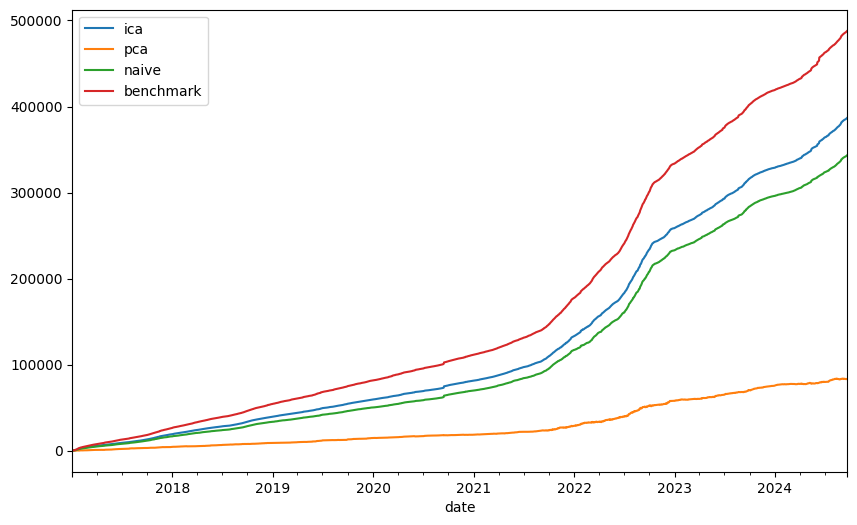

In [ ]:
df_revenues.cumsum().plot(figsize=(10,6))

array([[<Axes: title={'center': 'ica'}>, <Axes: title={'center': 'pca'}>],
       [<Axes: title={'center': 'naive'}>,
        <Axes: title={'center': 'benchmark'}>]], dtype=object)

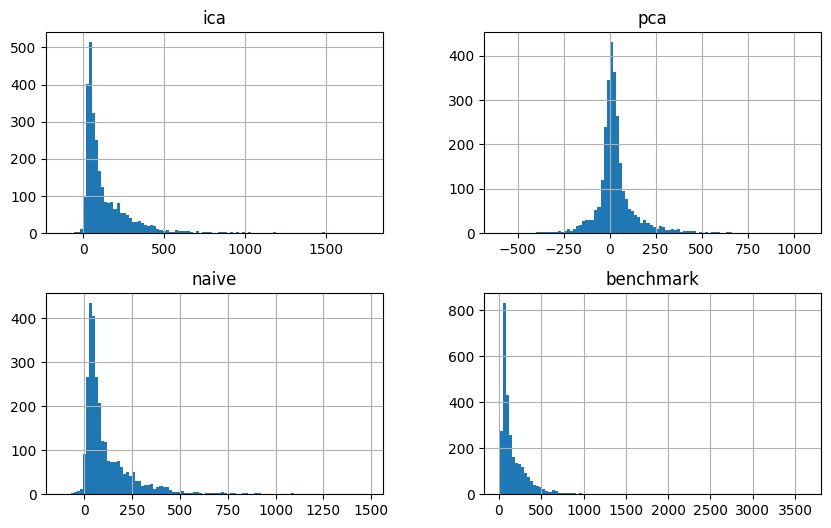

In [ ]:
df_revenues.hist(bins=100, figsize=(10,6))

<Axes: title={'center': 'Total Revenues'}>

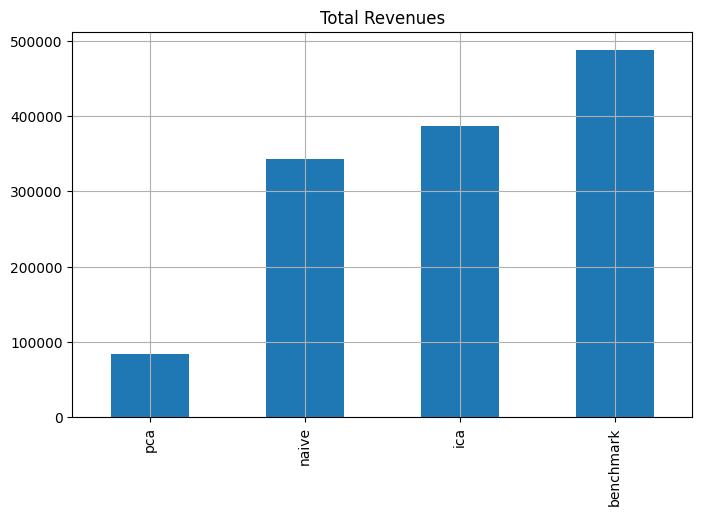

In [ ]:
plt.title("Total Revenues")
df_revenues.sum().sort_values().plot.bar(figsize=(8,5), grid=True)

Text(0.5, 1.0, 'Yearly Revenues')

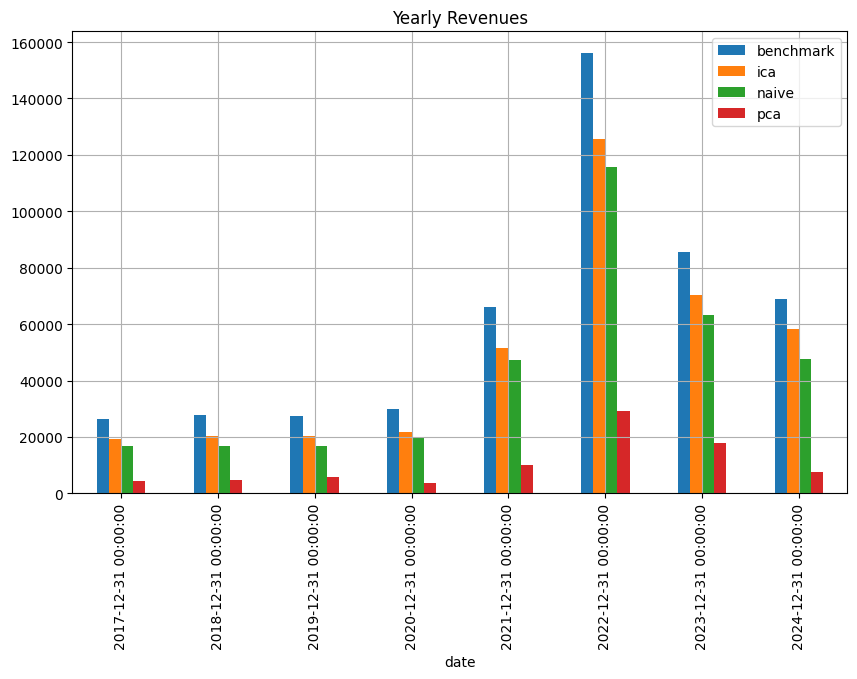

In [ ]:
yearly_revenues = df_revenues[["benchmark", "ica", "naive", "pca"]].resample("YE").sum()
yearly_revenues.plot.bar(figsize=(10,6), grid=True)
plt.title("Yearly Revenues")

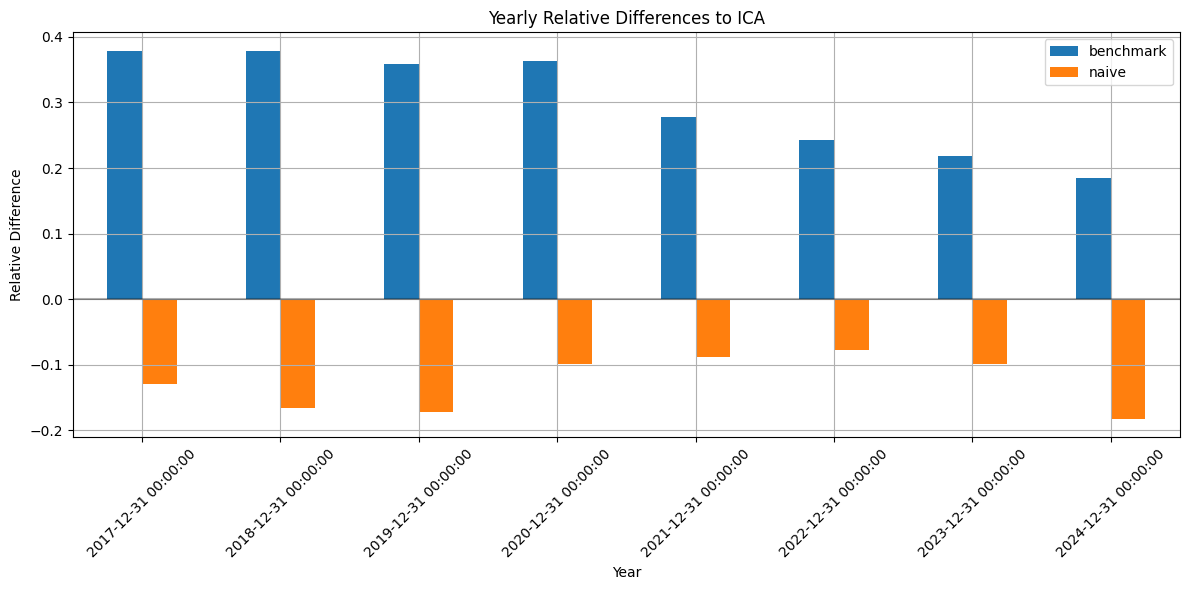

In [ ]:
# Compute relative differences to ICA per year
relative_diff_yearly = yearly_revenues.div(yearly_revenues['ica'], axis=0) - 1
relative_diff_yearly = relative_diff_yearly.drop(columns=['ica', "pca"])  # Remove ICA column since it's always 0

# Plot relative differences
relative_diff_yearly.plot.bar(figsize=(12, 6), grid=True)
plt.title("Yearly Relative Differences to ICA")
plt.ylabel("Relative Difference")
plt.xlabel("Year")
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
print("ICA vs PCA p-value:", round(mannwhitneyu(df_revenues['ica'], df_revenues['pca'], alternative="greater").pvalue, 4), "relative difference:", round((df_revenues['ica'].sum() - df_revenues['pca'].sum()) / abs(df_revenues['pca'].sum()), 4))
print("ICA vs Naive p-value:", round(mannwhitneyu(df_revenues['ica'], df_revenues['naive'], alternative="greater").pvalue, 4), "relative difference:", round((df_revenues['ica'].sum() - df_revenues['naive'].sum()) / abs(df_revenues['naive'].sum()), 4))
print("ICA vs Benchmark p-value:", round(mannwhitneyu(df_revenues['ica'], df_revenues['benchmark'], alternative="greater").pvalue, 4), "relative difference:", round((df_revenues['ica'].sum() - df_revenues['benchmark'].sum()) / abs(df_revenues['benchmark'].sum()), 4))

ICA vs PCA p-value: 0.0 relative difference: 3.6488
ICA vs Naive p-value: 0.0 relative difference: 0.1264
ICA vs Benchmark p-value: 1.0 relative difference: -0.2071
